In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(
    host='localhost',
    user='',
    password='',
    database='job'
)
query = "SELECT skills FROM job_market"
df = pd.read_sql(query, db)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5764\1383283845.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


<!-- 1.	What are the top 10 most in-demand skills across all job postings?  -->

#  1.	What are the top 10 most in-demand skills across all job postings? 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5764\2047399634.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db).dropna()


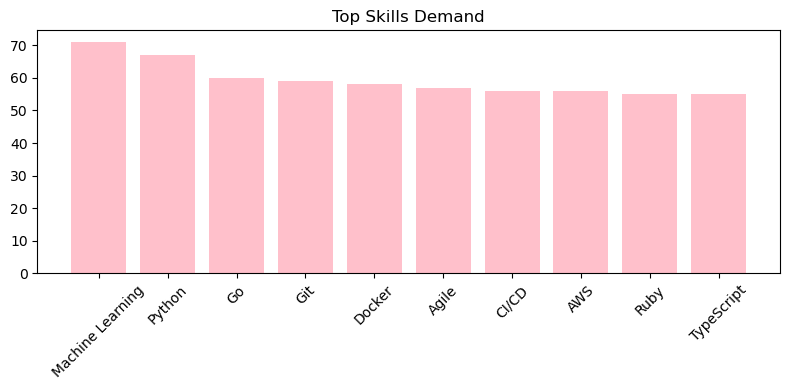

In [2]:
query = "SELECT skills FROM job_market"

df = pd.read_sql(query, db).dropna()

skills = df["skills"].str.split(",").explode().str.strip()

top_skills = skills.value_counts().head(10)

plt.figure(figsize=(8,4))

plt.bar(top_skills.index, top_skills.values, color="pink")

plt.xticks(rotation=45)
plt.title("Top Skills Demand")
plt.tight_layout()
plt.show()

# 2.	Is Python more in demand than SQL, Power BI, Tableau, or Excel? 

In [9]:
query = "SELECT skills FROM job_market"
df = pd.read_sql(query, db).dropna()

skills = df["skills"].str.split(",").explode().str.strip()

result = skills.value_counts().reset_index()
result.columns = ["skills", "count"]

print(result)

              skills  count
0   Machine Learning     71
1             Python     67
2                 Go     60
3                Git     59
4             Docker     58
5              Agile     57
6              CI/CD     56
7                AWS     56
8               Ruby     55
9         TypeScript     55
10        JavaScript     54
11         REST APIs     53
12           Node.js     52
13             React     52
14               SQL     51
15        Kubernetes     48
16              Java     47
17        TensorFlow     43
18           MongoDB     38
19                        7


C:\Users\lenovo\AppData\Local\Temp\ipykernel_6800\58058231.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db).dropna()


# 3.	Which skills are required for entry-level roles? 

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\569030284.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, db)


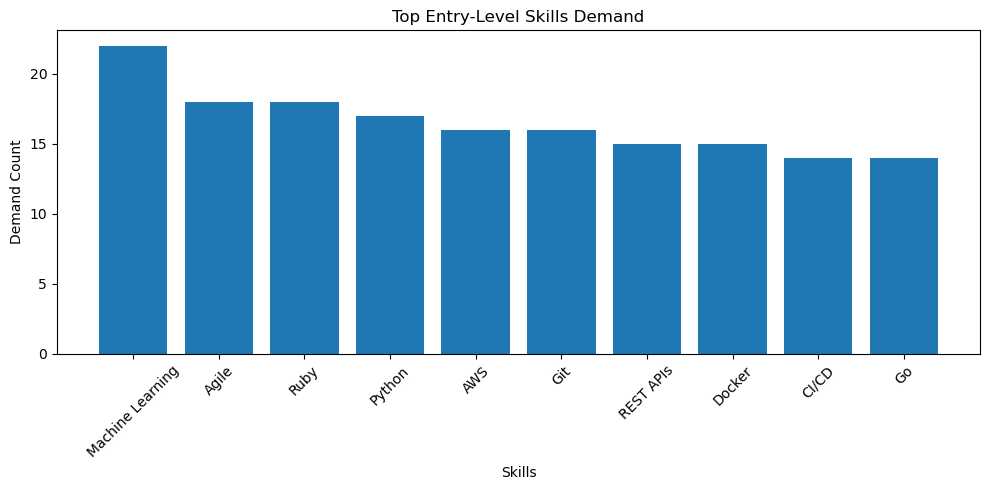

In [12]:
query = """
SELECT skills
FROM job_market
WHERE experience_required <= 2;
"""
df = pd.read_sql(query, db)
df["skills"] = df["skills"].str.split(",\s*")
df = df.explode("skills")
df["skills"] = df["skills"].str.strip()

skill_counts = df["skills"].value_counts().head(10).reset_index()
skill_counts.columns = ["skills", "demand_count"]

plt.figure(figsize=(10,5))
plt.bar(skill_counts["skills"], skill_counts["demand_count"])

plt.title("Top Entry-Level Skills Demand")
plt.xlabel("Skills")
plt.ylabel("Demand Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 4. Which companies post the most jobs?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_6800\939588651.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)
C:\Users\lenovo\AppData\Local\Temp\ipykernel_6800\939588651.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result,x='total_jobs',y='company',palette='viridis')


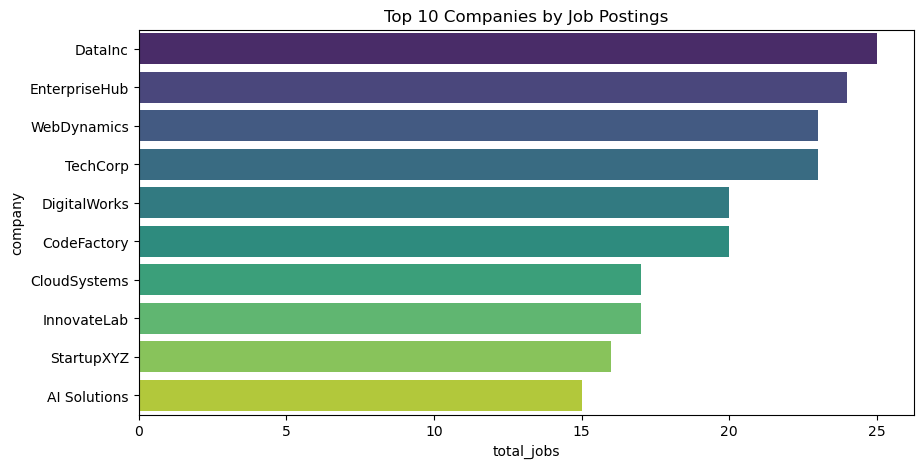

In [16]:
query="""SELECT company, COUNT(*) AS total_jobs
FROM job_market
GROUP BY company
ORDER BY total_jobs DESC
LIMIT 10"""

result=pd.read_sql(query,db)
plt.figure(figsize=(10,5))

sns.barplot(data=result,x='total_jobs',y='company',palette='viridis')

plt.title("Top 10 Companies by Job Postings")
plt.show()

# 5. Which job types are most offered (full time, part time, contract)?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\975055386.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


    job_type  total_jobs
0     Remote          55
1  Part-time          49
2  Full-time          50
3   Contract          49
4    manager           1
5  Full time           3


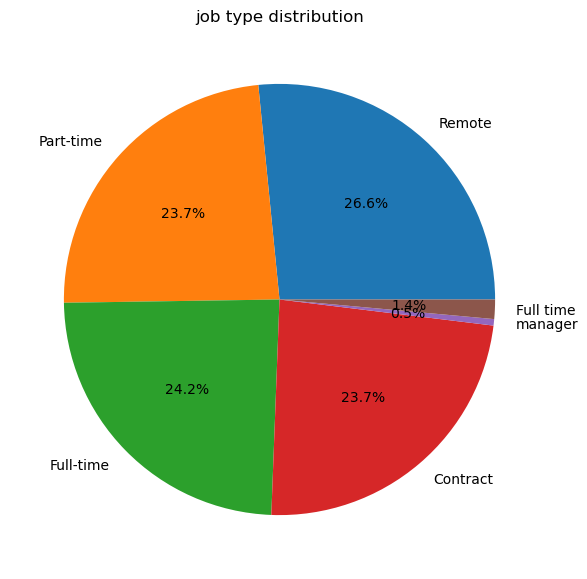

In [16]:
query="""select job_type,count(*) as total_jobs
from job_market
group by job_type"""

result=pd.read_sql(query,db)

print(result)

plt.figure(figsize=(7,7))
plt.pie(result['total_jobs'],labels=result['job_type'],autopct='%1.1f%%')
plt.title("job type distribution")
plt.show()

# 6. Which locations have highest average salary?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\2897309669.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


            location     avg_salary
0        Seattle, WA  159760.615385
1  San Francisco, CA  158337.750000
2       New York, NY  149383.025000
3             Berlin  142500.000000
4             Munich  140000.000000
5         London, UK  135824.550000
6        Atlanta, GA  125708.911765
7         Denver, CO  122737.575000
8             Remote  118953.062500
9         Boston, MA  118052.347826


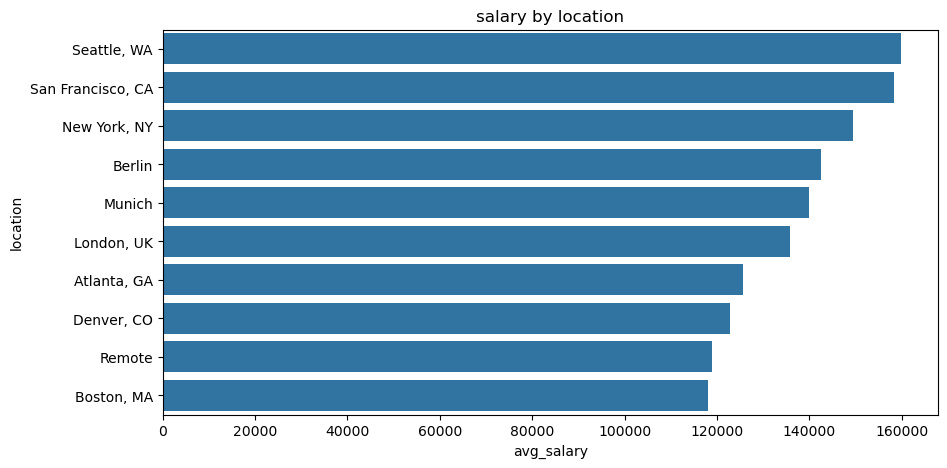

In [17]:
query="""select location,avg((salary_min+salary_max)/2) as avg_salary
from job_market
group by location
order by avg_salary desc
limit 10"""

result=pd.read_sql(query,db)

print(result)

plt.figure(figsize=(10,5))
sns.barplot(data=result,x='avg_salary',y='location')
plt.title("salary by location")
plt.show()

# 7. Which companies offer highest salary packages?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\241205400.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


         company     avg_salary
0     Automat-it  150000.000000
1         Skalar  140000.000000
2   Paymentology  140000.000000
3      SolarEdge  140000.000000
4        DataInc  139035.020000
5  EnterpriseHub  133273.250000
6    WebDynamics  130487.739130
7   DigitalWorks  130429.275000
8   AI Solutions  128877.000000
9   CloudSystems  126869.441176


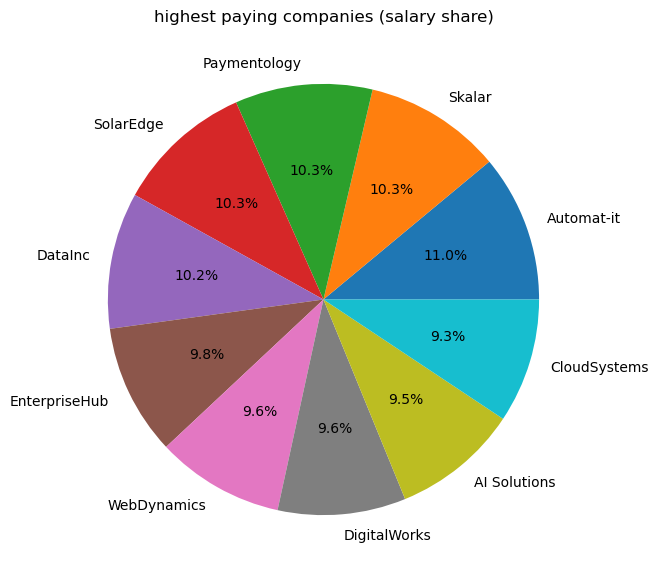

In [26]:
query="""select company,avg((salary_min+salary_max)/2) as avg_salary
from job_market
group by company
order by avg_salary desc
limit 10"""

result=pd.read_sql(query,db)

print(result)

plt.figure(figsize=(7,7))
plt.pie(result['avg_salary'],labels=result['company'],autopct='%1.1f%%')
plt.title("highest paying companies (salary share)")
plt.show()

# 8. Which job categories require the most experience?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\4205657476.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


                    category  avg_exp
0                     Remote      5.5
1                 Technology      4.2
2  Recruitment and Selection      2.0


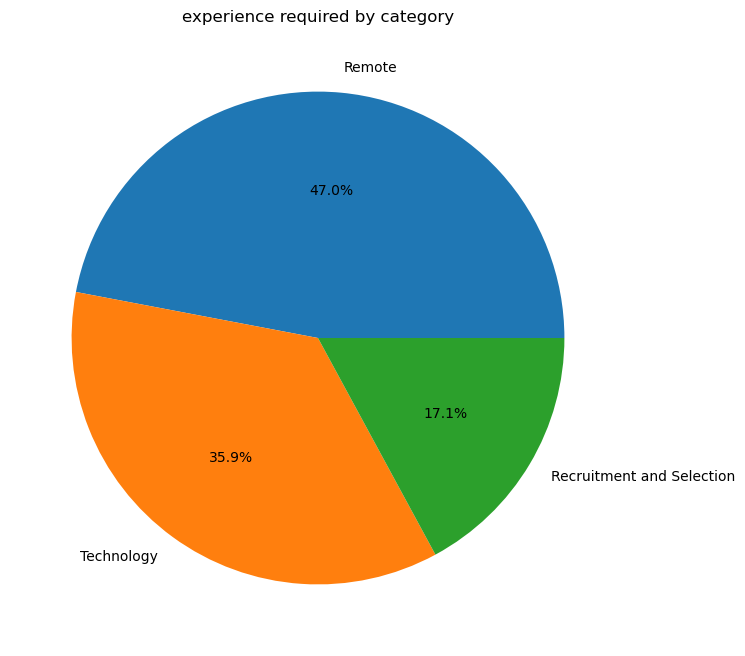

In [19]:
query="""select category,avg(experience_required) as avg_exp
from job_market
group by category
order by avg_exp desc"""

result=pd.read_sql(query,db)

print(result)

plt.figure(figsize=(8,8))
plt.pie(result['avg_exp'],labels=result['category'],autopct='%1.1f%%')
plt.title("experience required by category")
plt.show()

# 9. Which companies offer high salary vs low salary comparison?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\3590205361.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


         company     avg_salary
0     Automat-it  150000.000000
1         Skalar  140000.000000
2   Paymentology  140000.000000
3      SolarEdge  140000.000000
4        DataInc  139035.020000
5  EnterpriseHub  133273.250000
6    WebDynamics  130487.739130
7   DigitalWorks  130429.275000
8   AI Solutions  128877.000000
9   CloudSystems  126869.441176


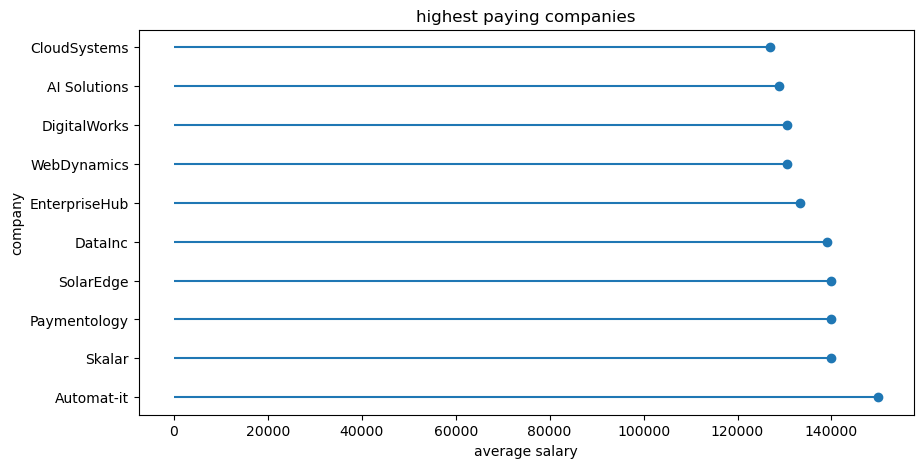

In [27]:
query="""select company,avg((salary_min+salary_max)/2) as avg_salary
from job_market
group by company
order by avg_salary desc
limit 10"""

result=pd.read_sql(query,db)

print(result)

plt.figure(figsize=(10,5))

plt.hlines(y=result['company'], xmin=0, xmax=result['avg_salary'])
plt.plot(result['avg_salary'], result['company'], "o")

plt.title("highest paying companies")
plt.xlabel("average salary")
plt.ylabel("company")

plt.show()

# 10. What is the salary distribution across all jobs?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_7764\192303673.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


   avg_salary
0    221213.5
1    218483.0
2    216222.0
3    202953.0
4    200362.5


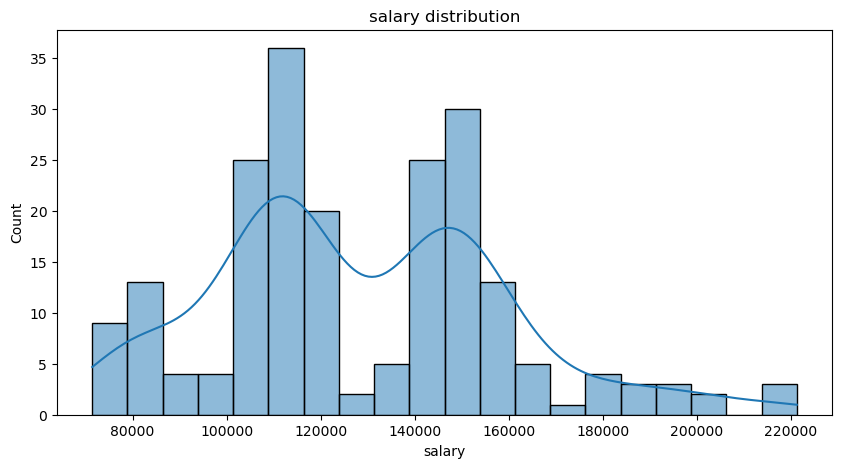

In [22]:
query="""select (salary_min+salary_max)/2 as avg_salary
from job_market"""

result=pd.read_sql(query,db)

print(result.head())

plt.figure(figsize=(10,5))
sns.histplot(result['avg_salary'],bins=20,kde=True)
plt.title("salary distribution")
plt.xlabel("salary")
plt.show()

# 11. Which job roles have the biggest salary gap?

C:\Users\lenovo\AppData\Local\Temp\ipykernel_6800\4108036307.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result = pd.read_sql(query, db)


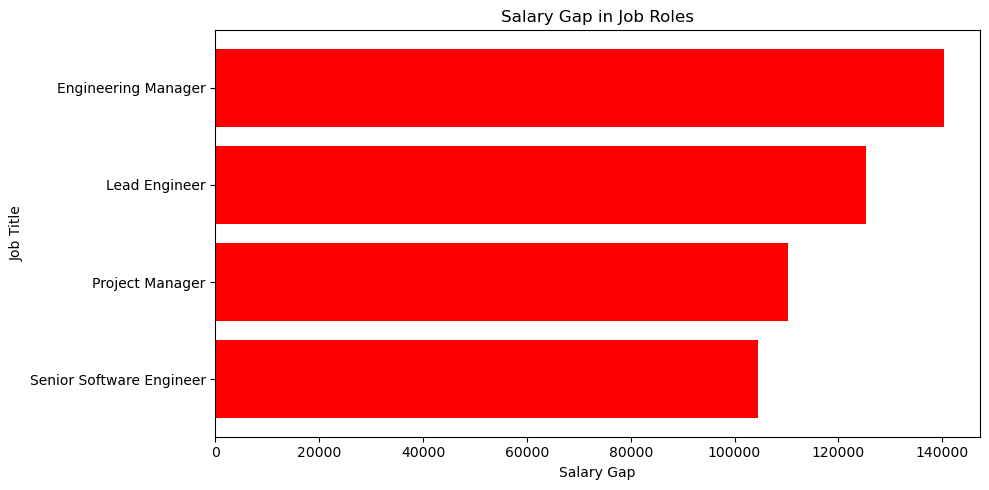

In [11]:
query = """
select job_title,(salary_max-salary_min) as salary_gap
from job_market
order by salary_gap desc
limit 10
"""

result = pd.read_sql(query, db)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.barh(result["job_title"], result["salary_gap"], color="red")

plt.title("Salary Gap in Job Roles")
plt.xlabel("Salary Gap")
plt.ylabel("Job Title")

plt.gca().invert_yaxis()  # highest at top
plt.tight_layout()
plt.show()

# 12. Relationship between experience and salary

C:\Users\lenovo\AppData\Local\Temp\ipykernel_6800\412432087.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result=pd.read_sql(query,db)


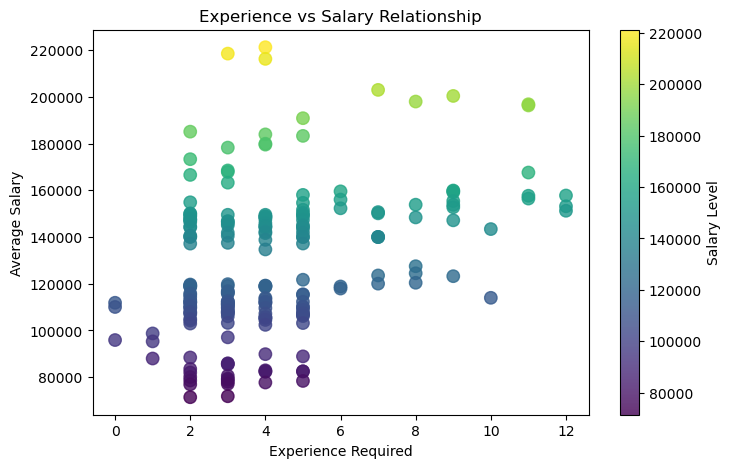

In [12]:
query="select experience_required,(salary_min+salary_max)/2 as avg_salary from job_market"

result=pd.read_sql(query,db)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(result["experience_required"],result["avg_salary"],
c=result["avg_salary"],cmap="viridis",s=80,alpha=0.8)

plt.title("Experience vs Salary Relationship")
plt.xlabel("Experience Required")
plt.ylabel("Average Salary")

plt.colorbar(label="Salary Level")

plt.show()